# 유튜버 이탈 예측 및 주요 원인 분석 모델

이 노트북은 새 EDA 전처리 산출물인 preprocessed_data/X.csv, y.csv를 기준으로 XGBoost 이탈 예측 모델을 구축합니다.

이번 버전의 목적은 column_info.csv와 중요도 진단 결과를 바탕으로 선별한 churn 핵심 피처만 사용하는 것입니다.

- 입력 데이터: notebooks/01_data_collection/EDA/preprocessed_data/X.csv, y.csv
- 제외: channel_identifier, is_churned, 민감 키워드 계열, 대부분의 장르 OHE, collected_video_count
- 포함: 업로드 공백/규칙성, 채널 규모, 성과 피처 중심
- 결측치 대체는 Pipeline(SimpleImputer -> XGBClassifier) 안에서 train 데이터 기준으로 처리합니다.

## 1. 환경 설정 및 데이터 로드


In [1]:
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("shap") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    log_loss,
)
import warnings

warnings.filterwarnings('ignore')
available_fonts = {font.name for font in fm.fontManager.ttflist}
if 'Malgun Gothic' in available_fonts:
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif 'AppleGothic' in available_fonts:
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 새 EDA 전처리 산출물 로드
PREPROCESSED_DIR = '../../notebooks/01_data_collection/EDA/preprocessed_data'

X_all = pd.read_csv(f'{PREPROCESSED_DIR}/X.csv')
y_df = pd.read_csv(f'{PREPROCESSED_DIR}/y.csv')
column_info = pd.read_csv(f'{PREPROCESSED_DIR}/column_info.csv')

data = X_all.merge(y_df, on='channel_identifier', how='inner')

print(f"X_all shape: {X_all.shape}")
print(f"y shape: {y_df.shape}")
print(f"merged data shape: {data.shape}")
print()
print("타깃 분포:")
print(data['is_churned'].value_counts())
print(f"이탈 비율: {data['is_churned'].mean():.2%}")
print(f"다수 클래스 기준 baseline accuracy: {(1 - data['is_churned'].mean()):.2%}")


X_all shape: (3331, 42)
y shape: (3331, 2)
merged data shape: (3331, 43)

타깃 분포:
is_churned
0    2637
1     694
Name: count, dtype: int64
이탈 비율: 20.83%
다수 클래스 기준 baseline accuracy: 79.17%


## 2. 데이터 전처리 및 라벨링

이번 데이터는 EDA 단계에서 이미 전처리된 X.csv, y.csv를 사용합니다.

- y.csv의 is_churned가 타깃입니다.
- channel_identifier는 식별자이므로 학습 피처에서 제외합니다.
- column_info.csv와 중요도 진단 결과를 기준으로 churn 핵심 피처만 선택합니다.


In [3]:
print("column_info 요약:")
display_cols = ["column", "source", "role", "dtype", "null_count", "description"]
try:
    display(column_info[display_cols])
except NameError:
    print(column_info[display_cols].to_string(index=False))


column_info 요약:


,column,source,role,dtype,null_count,description
0,channel_identifier,channel_info_table,식별자,str,0,채널 식별자 (PK)
1,subscriber_count,channel_info_table,피처,int64,0,구독자 수
2,total_views,channel_info_table,피처,int64,0,채널 총 조회수
3,video_count,channel_info_table,피처,int64,0,채널 총 영상 수
4,channel_age_days,파생 (channel_info),피처,int64,0,"채널 나이 (기준일 기준 경과일, 우측절단 보정)"
5,collected_video_count,channel_analytics_table,피처,int64,0,수집된 영상 수 (최대 50)
6,avg_upload_interval_days,channel_analytics_table,피처,float64,0,"평균 업로드 간격 (일), 마지막 공백 제외"
7,std_upload_interval_days,channel_analytics_table,피처,float64,0,업로드 간격 표준편차
8,max_gap_days,channel_analytics_table,피처,float64,0,최대 업로드 공백 (일)
9,hiatus_count_30d,channel_analytics_table,피처,int64,0,30일 이상 공백 발생 횟수


## 3. 피처 엔지니어링

새 EDA 전처리 데이터에서는 업로드 공백/규칙성 계열이 가장 강한 churn 신호로 나타났습니다.

핵심 축:

1. 업로드 공백/규칙성: max_gap_days, gap_ratio, std_upload_interval_days, avg_upload_interval_days, regularity_score, cv, hiatus_count_30d
2. 채널 규모: video_count, subscriber_count, total_views, channel_age_days
3. 성과/반응: avg_normal_view, avg_comment_count, avg_like_count, avg_view_count, std_view_count

민감 키워드 계열과 대부분의 장르 OHE는 churn보다는 최종 risk 계산 또는 평판 리스크 축에 더 적합하므로 이번 XGB churn 모델에서는 제외합니다.


In [4]:
CHURN_CORE_FEATURES = [
    # 업로드 공백/규칙성 핵심 피처
    "max_gap_days",
    "gap_ratio",
    "std_upload_interval_days",
    "avg_upload_interval_days",
    "regularity_score",
    "cv",
    "hiatus_count_30d",

    # 채널 규모/운영 기간
    "video_count",
    "subscriber_count",
    "total_views",
    "channel_age_days",

    # 성과/반응 보조 피처
    "avg_normal_view",
    "avg_comment_count",
    "avg_like_count",
    "avg_view_count",
    "std_view_count",
]

missing_features = [feature for feature in CHURN_CORE_FEATURES if feature not in data.columns]
if missing_features:
    raise ValueError(f"데이터에 없는 피처가 있습니다: {missing_features}")

feature_info = column_info[column_info["column"].isin(CHURN_CORE_FEATURES)].copy()
feature_info["selected_order"] = feature_info["column"].map(
    {feature: idx + 1 for idx, feature in enumerate(CHURN_CORE_FEATURES)}
)
feature_info = feature_info.sort_values("selected_order")

print(f"선택 피처 수: {len(CHURN_CORE_FEATURES)}")
try:
    display(feature_info[["selected_order", "column", "source", "description"]])
except NameError:
    print(feature_info[["selected_order", "column", "source", "description"]].to_string(index=False))


선택 피처 수: 16


,selected_order,column,source,description
8,1,max_gap_days,channel_analytics_table,최대 업로드 공백 (일)
18,2,gap_ratio,channel_score_table,긴 공백 비율
7,3,std_upload_interval_days,channel_analytics_table,업로드 간격 표준편차
6,4,avg_upload_interval_days,channel_analytics_table,"평균 업로드 간격 (일), 마지막 공백 제외"
15,5,regularity_score,channel_score_table,"업로드 규칙성 점수 (0~1, 높을수록 규칙적) ⭐핵심"
16,6,cv,channel_score_table,업로드 간격 변동계수 (CV)
9,7,hiatus_count_30d,channel_analytics_table,30일 이상 공백 발생 횟수
3,8,video_count,channel_info_table,채널 총 영상 수
1,9,subscriber_count,channel_info_table,구독자 수
2,10,total_views,channel_info_table,채널 총 조회수


### 피처(Feature) 설명

#### 선택한 핵심 피처

**업로드 공백/규칙성**
- max_gap_days: 최대 업로드 공백
- gap_ratio: 긴 공백 비율
- std_upload_interval_days: 업로드 간격 표준편차
- avg_upload_interval_days: 평균 업로드 간격
- regularity_score: 업로드 규칙성 점수, 낮을수록 위험
- cv: 업로드 간격 변동계수
- hiatus_count_30d: 30일 이상 공백 횟수

**채널 규모**
- video_count
- subscriber_count
- total_views
- channel_age_days

**성과/반응**
- avg_normal_view
- avg_comment_count
- avg_like_count
- avg_view_count
- std_view_count

#### 제외한 피처

- channel_identifier: 식별자
- collected_video_count: 대부분 수집 정책의 흔적에 가까워 중요도 낮음
- sensitive_score, n_sensitive_videos, sensitive_video_ratio, cat_*: 평판 리스크 축에 더 적합
- 대부분의 genre_*: churn 인과보다는 장르별 운영 패턴 보조 신호라 이번 핵심 모델에서는 제외


In [5]:
ALL_FEATURES = CHURN_CORE_FEATURES
merged_df = data[["channel_identifier", "is_churned"] + ALL_FEATURES].copy()

print(f"학습 데이터 행 수: {len(merged_df):,}")
print(f"학습 피처 수: {len(ALL_FEATURES)}")
print()
print("피처별 결측치:")
missing = merged_df[ALL_FEATURES].isnull().sum().sort_values(ascending=False)
print(missing[missing > 0] if (missing > 0).any() else "  없음")


학습 데이터 행 수: 3,331
학습 피처 수: 16

피처별 결측치:
  없음


In [6]:
EXCLUDED_FEATURE_GROUPS = {
    "identifier": ["channel_identifier"],
    "low_churn_signal": ["collected_video_count"],
    "reputation_risk": [
        "sensitive_score",
        "n_sensitive_videos",
        "sensitive_video_ratio",
        "cat_politics",
        "cat_hate",
        "cat_aggro",
        "cat_adult_illegal",
    ],
    "genre_ohe": [column for column in data.columns if column.startswith("genre_")],
}

print("이번 XGB churn 학습에서 제외한 주요 피처 그룹:")
for group, features in EXCLUDED_FEATURE_GROUPS.items():
    existing = [feature for feature in features if feature in data.columns]
    print(f"- {group}: {len(existing)}개")
    print(existing)


이번 XGB churn 학습에서 제외한 주요 피처 그룹:
- identifier: 1개
['channel_identifier']
- low_churn_signal: 1개
['collected_video_count']
- reputation_risk: 7개
['sensitive_score', 'n_sensitive_videos', 'sensitive_video_ratio', 'cat_politics', 'cat_hate', 'cat_aggro', 'cat_adult_illegal']
- genre_ohe: 16개
['genre_BJ+연예인+인물', 'genre_IT+기술+컴퓨터', 'genre_TV+방송', 'genre_가수+댄스+음악', 'genre_강의+교육', 'genre_게임', 'genre_경제+부동산+주식', 'genre_국내+여행+해외', 'genre_라이프+취미', 'genre_레시피+요리+음식', 'genre_만화+애니+영화', 'genre_미용+패션', 'genre_반려동물+애완', 'genre_스포츠+운동', 'genre_어린이+키즈', 'genre_자동차']


In [7]:
# 선택 피처의 타깃별 평균 차이를 확인합니다.
summary_by_target = merged_df.groupby("is_churned")[ALL_FEATURES].mean().T
summary_by_target.columns = ["active_mean", "churned_mean"]
summary_by_target["diff_churned_minus_active"] = (
    summary_by_target["churned_mean"] - summary_by_target["active_mean"]
)
summary_by_target = summary_by_target.loc[ALL_FEATURES]

try:
    display(summary_by_target.round(3))
except NameError:
    print(summary_by_target.round(3).to_string())


,active_mean,churned_mean,diff_churned_minus_active
max_gap_days,6.778400e+01,2.652520e+02,1.974680e+02
gap_ratio,6.753000e+00,1.423700e+01,7.483000e+00
std_upload_interval_days,1.191300e+01,4.300400e+01,3.109200e+01
avg_upload_interval_days,6.260000e+00,1.597800e+01,9.718000e+00
regularity_score,6.530000e-01,5.110000e-01,-1.430000e-01
cv,1.285000e+00,2.325000e+00,1.040000e+00
hiatus_count_30d,1.600000e+00,4.331000e+00,2.731000e+00
video_count,1.318143e+03,6.784710e+02,-6.396720e+02
subscriber_count,3.627152e+05,2.900865e+05,-7.262875e+04
total_views,2.167731e+08,1.260683e+08,-9.070476e+07


In [8]:
# 최종 학습 테이블
print(merged_df.head())


  channel_identifier  is_churned  max_gap_days  gap_ratio  \
0            CH03270           0        1393.0      22.87   
1            CH03271           0         321.0       9.76   
2            CH03272           0          72.0       5.10   
3            CH03273           1         360.0      15.92   
4            CH03274           0          26.0       9.23   

   std_upload_interval_days  avg_upload_interval_days  regularity_score  \
0                    203.50                     60.90            0.4029   
1                     58.38                     32.90            0.4688   
2                     17.66                     14.12            0.6316   
3                     71.67                     22.61            0.4077   
4                      4.96                      2.82            0.4785   

      cv  hiatus_count_30d  video_count  subscriber_count  total_views  \
0  3.342                 9           77            100000     45370000   
1  1.775                14        

In [9]:
merged_df.head()

,channel_identifier,is_churned,max_gap_days,gap_ratio,std_upload_interval_days,avg_upload_interval_days,regularity_score,cv,hiatus_count_30d,video_count,subscriber_count,total_views,channel_age_days,avg_normal_view,avg_comment_count,avg_like_count,avg_view_count,std_view_count
0,CH03270,0,1393.0,22.87,203.50,60.90,0.4029,3.342,9,77,100000,45370000,3849,426053.80,236.82,4315.10,426053.80,567727.54
1,CH03271,0,321.0,9.76,58.38,32.90,0.4688,1.775,14,448,100000,8860000,4408,1035.42,9.32,61.90,1035.42,1024.21
2,CH03272,0,72.0,5.10,17.66,14.12,0.6316,1.251,10,2040,100000,30210000,3801,5593.14,21.66,62.90,5020.40,4387.90
3,CH03273,1,360.0,15.92,71.67,22.61,0.4077,3.170,5,112,100000,9650000,5128,58799.55,176.76,483.32,55364.56,57049.86
4,CH03274,0,26.0,9.23,4.96,2.82,0.4785,1.761,0,252,100000,195810000,5066,83236.78,120.26,3449.08,296493.48,332015.98


In [10]:
X = merged_df[ALL_FEATURES].copy()
y = merged_df['is_churned'].copy()

print(f"Feature count: {len(ALL_FEATURES)}")
print(ALL_FEATURES)
print()
print("타깃 분포:")
print(y.value_counts(normalize=True).rename("ratio").round(4))
print()
print("결측치 현황:")
missing = X.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0] if (missing > 0).any() else "  없음")


Feature count: 16
['max_gap_days', 'gap_ratio', 'std_upload_interval_days', 'avg_upload_interval_days', 'regularity_score', 'cv', 'hiatus_count_30d', 'video_count', 'subscriber_count', 'total_views', 'channel_age_days', 'avg_normal_view', 'avg_comment_count', 'avg_like_count', 'avg_view_count', 'std_view_count']

타깃 분포:
is_churned
0    0.7917
1    0.2083
Name: ratio, dtype: float64

결측치 현황:
  없음


In [11]:
RANDOM_STATE = 42
THRESHOLD_GRID = np.arange(0.05, 0.951, 0.01)
THRESHOLD_OBJECTIVE = "f1"  # accuracy보다 이탈 클래스 탐지력을 우선합니다.
model_results = {}


def make_train_valid_test_split(test_size=0.2, valid_size=0.25):
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full,
        y_train_full,
        test_size=valid_size,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )
    return X_train, X_valid, X_test, y_train, y_valid, y_test


def score_classifier(model, X_data):
    return model.predict_proba(X_data)[:, 1]


def calculate_binary_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "log_loss": log_loss(y_true, y_score),
    }


def threshold_key(metrics):
    if THRESHOLD_OBJECTIVE == "accuracy":
        return (metrics["accuracy"], metrics["f1"], metrics["recall"], metrics["precision"])
    return (metrics["f1"], metrics["recall"], metrics["precision"], metrics["roc_auc"])


def find_best_threshold(y_true, y_score):
    best_metrics = None
    best_key = None

    for threshold in THRESHOLD_GRID:
        metrics = calculate_binary_metrics(y_true, y_score, threshold)
        key = threshold_key(metrics)
        if best_key is None or key > best_key:
            best_key = key
            best_metrics = metrics

    return best_metrics


def show_table(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


def tune_model_candidates(model_name, candidates, score_func):
    rows = []
    best = None

    for idx, model_candidate in enumerate(candidates, start=1):
        model_candidate.fit(X_train, y_train)
        valid_score = np.clip(score_func(model_candidate, X_valid), 0, 1)
        valid_metrics = find_best_threshold(y_valid, valid_score)
        row = {"candidate": idx, **valid_metrics}
        rows.append(row)

        key = threshold_key(valid_metrics)
        if best is None or key > best["key"]:
            best = {
                "key": key,
                "candidate": idx,
                "model": model_candidate,
                "threshold": valid_metrics["threshold"],
                "valid_metrics": valid_metrics,
                "score_func": score_func,
            }

    summary = pd.DataFrame(rows).sort_values(
        ["f1", "recall", "precision", "roc_auc"], ascending=False
    ).reset_index(drop=True)
    print(f"=== {model_name}: validation tuning summary ({THRESHOLD_OBJECTIVE}) ===")
    show_table(summary)

    return best


def evaluate_tuned_model(model_name, result):
    y_score = np.clip(result["score_func"](result["model"], X_test), 0, 1)
    threshold = result["threshold"]
    y_pred = (y_score >= threshold).astype(int)
    test_metrics = calculate_binary_metrics(y_test, y_score, threshold)

    print(f"=== {model_name}: test metrics ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("confusion_matrix [[TN, FP], [FN, TP]]")
    print(confusion_matrix(y_test, y_pred))
    print(pd.Series(test_metrics).to_string())

    model_results[model_name] = {
        "candidate": result["candidate"],
        "threshold": threshold,
        "valid_metrics": result["valid_metrics"],
        "test_metrics": test_metrics,
        "model": result["model"],
    }

    return y_pred, y_score, test_metrics


X_train, X_valid, X_test, y_train, y_valid, y_test = make_train_valid_test_split()
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}, Valid churn rate: {y_valid.mean():.2%}, Test churn rate: {y_test.mean():.2%}")

Train: (1998, 16), Valid: (666, 16), Test: (667, 16)
Train churn rate: 20.82%, Valid churn rate: 20.87%, Test churn rate: 20.84%


## XGBClassifier

In [12]:
if XGBClassifier is None:
    model = None
    xgb_result = None
    xgb_pred = None
    xgb_prob = None
    print("xgboost is not installed. Skipping XGBClassifier training.")
else:
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    def make_xgb_pipeline(**params):
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                **params,
                scale_pos_weight=pos_weight,
                random_state=RANDOM_STATE,
                eval_metric='logloss',
                n_jobs=1,
            )),
        ])

    xgb_candidates = [
        make_xgb_pipeline(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, min_child_weight=1, reg_lambda=1),
        make_xgb_pipeline(n_estimators=500, max_depth=3, learning_rate=0.03, subsample=0.9, colsample_bytree=0.8, min_child_weight=3, reg_lambda=2),
        make_xgb_pipeline(n_estimators=300, max_depth=4, learning_rate=0.04, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_lambda=5),
        make_xgb_pipeline(n_estimators=400, max_depth=5, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=8),
    ]
    xgb_result = tune_model_candidates("XGBClassifier", xgb_candidates, score_classifier)
    model = xgb_result["model"]
    xgb_pred, xgb_prob, xgb_test_metrics = evaluate_tuned_model("XGBClassifier", xgb_result)

=== XGBClassifier: validation tuning summary (f1) ===


,candidate,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss
0,2,0.61,0.825826,0.574194,0.640288,0.605442,0.855555,0.613531,0.437444
1,4,0.64,0.836336,0.611940,0.589928,0.600733,0.846040,0.602975,0.423950
2,3,0.67,0.840841,0.632000,0.568345,0.598485,0.850463,0.617124,0.428643
3,1,0.67,0.833333,0.606061,0.575540,0.590406,0.851637,0.630099,0.433390


=== XGBClassifier: test metrics ===
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       528
           1       0.45      0.47      0.46       139

    accuracy                           0.77       667
   macro avg       0.65      0.66      0.65       667
weighted avg       0.77      0.77      0.77       667

confusion_matrix [[TN, FP], [FN, TP]]
[[447  81]
 [ 74  65]]
threshold    0.610000
accuracy     0.767616
precision    0.445205
recall       0.467626
f1           0.456140
roc_auc      0.776202
pr_auc       0.479646
log_loss     0.509226


In [13]:
if model is not None:
    test_result = merged_df.loc[X_test.index, ['channel_identifier']].copy()
    test_result['churn_prob'] = xgb_prob
    test_result['predicted_churn'] = xgb_pred
    test_result['is_churned'] = y_test.values
    test_result = test_result.sort_values('churn_prob', ascending=False).reset_index(drop=True)

    print("=== XGBClassifier test set: top 10 channels by churn probability ===")
    print(test_result.head(10).to_string(index=False))

    all_prob = model.predict_proba(X)[:, 1]
    channel_churn = merged_df[['channel_identifier']].copy()
    channel_churn['churn_prob'] = all_prob
    channel_churn['churn_prob_pct'] = (channel_churn['churn_prob'] * 100).round(2)
    channel_churn = channel_churn.sort_values('churn_prob', ascending=False).reset_index(drop=True)

    print()
    print("=== XGBClassifier all channels: top 10 by churn probability ===")
    print(channel_churn.head(10).to_string(index=False))

    # channel_churn.to_csv('../../data/processed/channel_churn_prob.csv', index=False)


=== XGBClassifier test set: top 10 channels by churn probability ===
channel_identifier  churn_prob  predicted_churn  is_churned
           CH03609    0.942941                1           0
           CH03593    0.942652                1           1
           CH04566    0.941295                1           0
           CH04497    0.940844                1           1
           CH04177    0.939336                1           1
           CH04836    0.936052                1           1
           CH05064    0.935637                1           1
           CH03858    0.934971                1           1
           CH05072    0.932558                1           1
           CH03668    0.930946                1           1

=== XGBClassifier all channels: top 10 by churn probability ===
channel_identifier  churn_prob  churn_prob_pct
           CH03688    0.964216       96.419998
           CH03857    0.960043       96.000000
           CH05207    0.956476       95.650002
           CH03404

## 원인 분석 (SHAP)
SHAP(SHapley Additive exPlanations)를 사용하여 각 피처가 이탈 예측에 미치는 영향을 분석합니다.

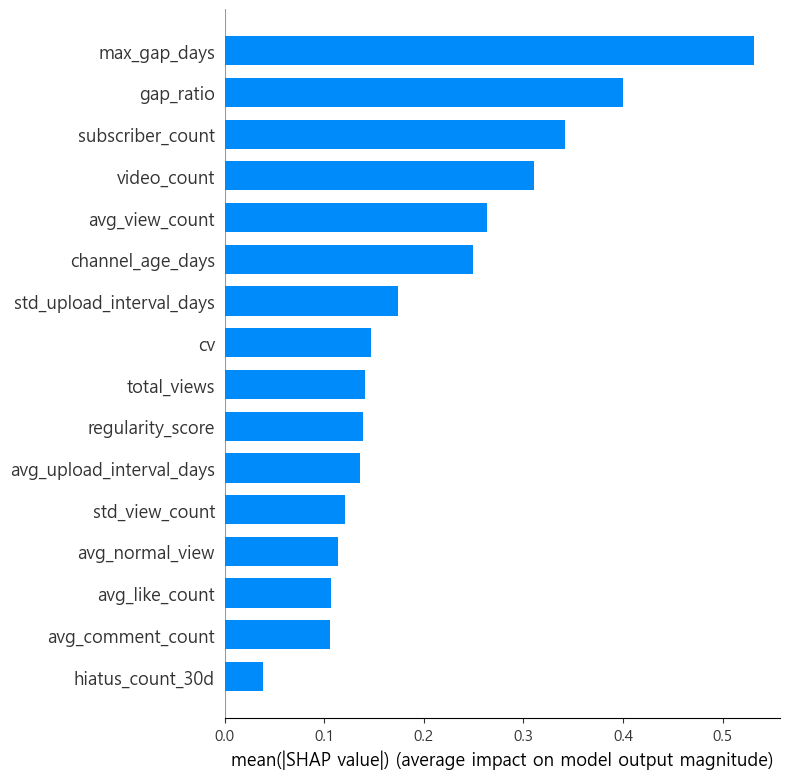

In [14]:
if model is None:
    explainer = None
    shap_values = None
    print("XGBClassifier was not trained. Skipping SHAP analysis.")
else:
    feature_names = list(X.columns)
    xgb_estimator = model.named_steps["model"]
    X_shap = pd.DataFrame(
        model.named_steps["imputer"].transform(X_test),
        columns=feature_names,
        index=X_test.index,
    )

    explainer = shap.TreeExplainer(xgb_estimator)
    shap_values = explainer.shap_values(X_shap)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [15]:
if model_results:
    comparison_rows = []
    for model_name, result in model_results.items():
        row = {
            "model": model_name,
            "candidate": result["candidate"],
            "threshold": result["threshold"],
        }
        row.update({f"test_{key}": value for key, value in result["test_metrics"].items()})
        comparison_rows.append(row)

    model_comparison = pd.DataFrame(comparison_rows).sort_values(
        ["test_f1", "test_recall", "test_precision", "test_roc_auc"], ascending=False
    ).reset_index(drop=True)
    print("=== Final model comparison sorted by F1 / recall ===")
    show_table(model_comparison)

=== Final model comparison sorted by F1 / recall ===


,model,candidate,threshold,test_threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_log_loss
0,XGBClassifier,2,0.61,0.61,0.767616,0.445205,0.467626,0.45614,0.776202,0.479646,0.509226


## 🎯 결론 및 모델 평가 (XGBoost)

**1. 이번 수정의 핵심**
* XGBoost 이탈 모델을 새 EDA 전처리 산출물인 preprocessed_data/X.csv, y.csv 기반으로 변경했습니다.
* column_info.csv와 중요도 진단 결과를 바탕으로 CHURN_CORE_FEATURES 16개만 사용합니다.
* 핵심 신호는 업로드 공백/규칙성 계열이며, 채널 규모와 성과 피처는 보조 신호로 둡니다.
* 민감 키워드 계열과 대부분의 장르 OHE는 churn 모델이 아니라 최종 risk 계산 또는 평판 리스크 축에서 다루는 편이 좋습니다.

**2. 평가 기준**
* accuracy만 보면 다수 클래스 영향 때문에 성능이 과대평가될 수 있습니다.
* threshold는 validation F1 기준으로 선택하고, 최종 평가는 F1, Recall, Precision, ROC-AUC, PR-AUC, confusion matrix를 함께 확인합니다.

**3. 해석**
* 이 노트북의 목적은 “이탈 여부를 맞히는 데 직접적인 운영 패턴 피처가 무엇인지”를 확인하는 것입니다.
* 최종 서비스 위험도에서는 이 churn 확률을 평판 리스크, 팬덤 리스크, 조회수 변동성 등과 별도 축으로 결합하는 편이 더 해석 가능합니다.
